# xGD per game state - Pogoń Grodzisk Mazowiecki (PGM)
### vs Polonia Bytom (PB), 2:2, StatsBomb `match_id` 4068759

Liczone z perspektywy Pogoni. `xG_PGM` - xG Pogoni Grodzisk Mazowiecki, `xG_PB` - xG Polonii Bytom, `xGD` to różnica.
Stany meczu: `leading` (prowadzenie) / `draw` (remis) / `trailing` (przegrywanie).

Opis i wnioski: **README.md**.

## 1. Dane

W pliku każdy strzał jest powielony raz na zawodnika z freeze frame'u, więc najpierw deduplikacja po `id`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, Arc, Polygon

rng = np.random.default_rng(20260909)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

CSV = "Polonia Bytom_Pogo  Grodzisk Mazowiecki_4068759.csv"
raw = pd.read_csv(CSV, low_memory=False)          # z freeze frame'ami - potrzebne w sekcji 8
df = raw.drop_duplicates("id").copy()

print(f"wiersze: {len(raw)} -> eventy: {len(df)}")
print(f"strzały: {(df.event_type_name=='Shot').sum()}, gole: {(df.outcome_name=='Goal').sum()}")
print(f"karne: {int(df.penalty.fillna(False).sum())}, czerwone kartki: {int(df.card_name.astype(str).str.contains('Red|Second').sum())}")

wiersze: 3892 -> eventy: 3232
strzały: 34, gole: 4
karne: 0, czerwone kartki: 0


## 2. Zegar, gole, segmenty

StatsBomb w drugiej połowie liczy minuty od 45:00, więc surowy czas cofa się na przerwie, więc łączę okresy po `Half End`.

In [2]:
PERIOD_START_MIN = {1: 0, 2: 45}          # minuta, od której StatsBomb liczy daną połowę
ends = (df[df.event_type_name == "Half End"]
        .assign(t=lambda d: d.minute * 60 + d.second).groupby("period").t.max())
offset, acc = {}, 0
for p in sorted(df.period.unique()):
    offset[p] = acc
    acc += ends[p] - PERIOD_START_MIN[p] * 60
TOTAL_SEC = acc
df["t"] = (df.minute * 60 + df.second - df.period.map(PERIOD_START_MIN) * 60 + df.period.map(offset))

TEAMS = sorted(df.team_name.dropna().unique())
PGM = "Pogoń Grodzisk Mazowiecki"         # drużyna, z której perspektywy liczone są xG i stany meczu
PB  = "Polonia Bytom"
US, THEM = PGM, PB                        # perspektywa analizy
OPP = {PGM: PB, PB: PGM}
COL = {PGM: "blue", PB: "red"}     # PGM niebieski, PB czerwony
STATES = ["leading", "draw", "trailing"]
MIRROR = {"leading": "trailing", "draw": "draw", "trailing": "leading"}

goals = df[(df.event_type_name == "Shot") & (df.outcome_name == "Goal")].sort_values("t")

def score_before(ts, team):
    p = goals[goals.t < ts]
    return int((p.team_name == team).sum()), int((p.team_name == OPP[team]).sum())

def state_of(gf, ga):
    return "leading" if gf > ga else ("trailing" if gf < ga else "draw")

print(f"czas gry: {TOTAL_SEC/60:.1f} min\n")
goals.assign(zegar=goals.minute.astype(str) + ":" + goals.second.astype(str).str.zfill(2),
             xG=goals.statsbomb_xg.round(3))[["period", "zegar", "team_name", "player_name", "xG"]]

czas gry: 94.4 min



,period,zegar,team_name,player_name,xG
782,1,21:13,Pogoń Grodzisk Mazowiecki,Kacper Los,0.198
1073,1,27:43,Polonia Bytom,Lucjan Zielinski,0.035
1409,1,36:18,Polonia Bytom,Maciej Wolski,0.093
1705,2,45:37,Pogoń Grodzisk Mazowiecki,Radoslaw Majewski,0.010


In [3]:
edges = [0.0] + list(goals.t.astype(float)) + [float(TOTAL_SEC)]
rows = []
for s0, s1 in zip(edges[:-1], edges[1:]):
    gf, ga = score_before(s0 + 1e-9, PGM)
    rows.append(dict(start=f"{int(s0//60)}:{int(s0%60):02d}", end=f"{int(s1//60)}:{int(s1%60):02d}",
                     minutes=round((s1 - s0) / 60, 1), score=f"{gf}:{ga}",
                     state_PGM=state_of(gf, ga)))
pd.DataFrame(rows)

,start,end,minutes,score,state_PGM
0,0:00,21:13,21.2,0:0,draw
1,21:13,27:43,6.5,1:0,leading
2,27:43,36:18,8.6,1:1,draw
3,36:18,45:42,9.4,1:2,trailing
4,45:42,94:24,48.7,2:2,draw


## 3. Wynik

In [4]:
shots = df[df.event_type_name == "Shot"].copy()
shots["state"] = [state_of(*score_before(r.t, r.team_name)) for r in shots.itertuples()]
shots["set_piece"] = shots.play_pattern_name.isin(["From Corner", "From Free Kick", "From Throw In"])

minutes = {tm: dict.fromkeys(STATES, 0.0) for tm in TEAMS}
for s0, s1 in zip(edges[:-1], edges[1:]):
    gf, ga = score_before(s0 + 1e-9, PGM)
    minutes[PGM][state_of(gf, ga)] += (s1 - s0) / 60
    minutes[PB][state_of(ga, gf)] += (s1 - s0) / 60

rows = []
for st in STATES:
    f  = shots[(shots.team_name == PGM) & (shots.state == st)]              # strzały PGM
    ag = shots[(shots.team_name == PB)  & (shots.state == MIRROR[st])]      # strzały PB z tego samego okna
    mins = minutes[PGM][st]
    rows.append(dict(state=st, minutes=round(mins, 1),
                     shots_PGM=len(f), xG_PGM=round(f.statsbomb_xg.sum(), 3),
                     xG_per_shot_PGM=round(f.statsbomb_xg.mean(), 3) if len(f) else np.nan,
                     shots_PB=len(ag), xG_PB=round(ag.statsbomb_xg.sum(), 3),
                     xGD=round(f.statsbomb_xg.sum() - ag.statsbomb_xg.sum(), 3),
                     xGD_per90=round((f.statsbomb_xg.sum() - ag.statsbomb_xg.sum()) / mins * 90, 3) if mins else np.nan))
table = pd.DataFrame(rows)
table

,state,minutes,shots_PGM,xG_PGM,xG_per_shot_PGM,shots_PB,xG_PB,xGD,xGD_per90
0,leading,6.5,2,0.117,0.059,2,0.079,0.038,0.525
1,draw,78.5,10,0.609,0.061,17,0.923,-0.314,-0.360
2,trailing,9.4,2,0.017,0.008,1,0.066,-0.050,-0.475


In [5]:
# kontrola: rozbicie na stany musi zsumować się do całego meczu
tot = shots.groupby("team_name").statsbomb_xg.agg(shots="count", xG="sum").round(3)
assert np.isclose(table.minutes.sum(), TOTAL_SEC / 60, atol=0.1)
assert np.isclose(table.xG_PGM.sum(), tot.loc[PGM, "xG"], atol=1e-3)
assert np.isclose(table.xG_PB.sum(),  tot.loc[PB,  "xG"], atol=1e-3)
tot

,shots,xG
team_name,,
Pogoń Grodzisk Mazowiecki,14,0.743
Polonia Bytom,20,1.069


In [6]:
# to samo z perspektywy Polonii: lustrzane odbicie, bo leading PGM to trailing PB
rows = []
for st in STATES:
    f  = shots[(shots.team_name == PB)  & (shots.state == st)]
    ag = shots[(shots.team_name == PGM) & (shots.state == MIRROR[st])]
    mins = minutes[PB][st]
    diff = f.statsbomb_xg.sum() - ag.statsbomb_xg.sum()
    rows.append(dict(state=st, minutes=round(mins, 1),
                     shots_PB=len(f), xG_PB=round(f.statsbomb_xg.sum(), 3),
                     xG_per_shot_PB=round(f.statsbomb_xg.mean(), 3) if len(f) else np.nan,
                     shots_PGM=len(ag), xG_PGM=round(ag.statsbomb_xg.sum(), 3),
                     xGD=round(diff, 3),
                     xGD_per90=round(diff / mins * 90, 3) if mins else np.nan))

table_PB = pd.DataFrame(rows)
assert np.isclose(table_PB.xGD.sum(), -table.xGD.sum(), atol=1e-9)   # musi być lustrem
table_PB

,state,minutes,shots_PB,xG_PB,xG_per_shot_PB,shots_PGM,xG_PGM,xGD,xGD_per90
0,leading,9.4,1,0.066,0.066,2,0.017,0.050,0.475
1,draw,78.5,17,0.923,0.054,10,0.609,0.314,0.360
2,trailing,6.5,2,0.079,0.040,2,0.117,-0.038,-0.525


Rozbicie na konkretny wynik. Tabela wyżej to jego zsumowanie: `0:0` i `1:1` i `2:2` składają się na `draw`.

In [7]:
# to samo w rozbiciu na konkretny wynik na tablicy (PGM:PB), a nie tylko leading/draw/trailing
def score_label(ts):
    gf, ga = score_before(ts, PGM)
    return f"{gf}:{ga}"

shots["score"] = [score_label(r.t) for r in shots.itertuples()]

seg_min = {}
for s0, s1 in zip(edges[:-1], edges[1:]):
    lab = score_label(s0 + 1e-9)
    seg_min[lab] = seg_min.get(lab, 0.0) + (s1 - s0) / 60      # kolejność = kolejność w meczu

rows = []
for lab, mins in seg_min.items():
    f = shots[(shots.team_name == PGM) & (shots.score == lab)]
    a = shots[(shots.team_name == PB)  & (shots.score == lab)]
    gf, ga = map(int, lab.split(":"))
    rows.append(dict(score_PGM_PB=lab, state_PGM=state_of(gf, ga), minutes=round(mins, 1),
                     shots_PGM=len(f), xG_PGM=round(f.statsbomb_xg.sum(), 3),
                     shots_PB=len(a),  xG_PB=round(a.statsbomb_xg.sum(), 3),
                     xGD=round(f.statsbomb_xg.sum() - a.statsbomb_xg.sum(), 3)))

by_score = pd.DataFrame(rows)
assert np.isclose(by_score.minutes.sum(), TOTAL_SEC / 60, atol=0.1)
assert by_score.shots_PGM.sum() + by_score.shots_PB.sum() == len(shots)
by_score

,score_PGM_PB,state_PGM,minutes,shots_PGM,xG_PGM,shots_PB,xG_PB,xGD
0,0:0,draw,21.2,1,0.198,4,0.229,-0.032
1,1:0,leading,6.5,2,0.117,2,0.079,0.038
2,1:1,draw,8.6,2,0.046,3,0.191,-0.145
3,1:2,trailing,9.4,2,0.017,1,0.066,-0.050
4,2:2,draw,48.7,7,0.365,10,0.503,-0.137


## 4. Wykresy

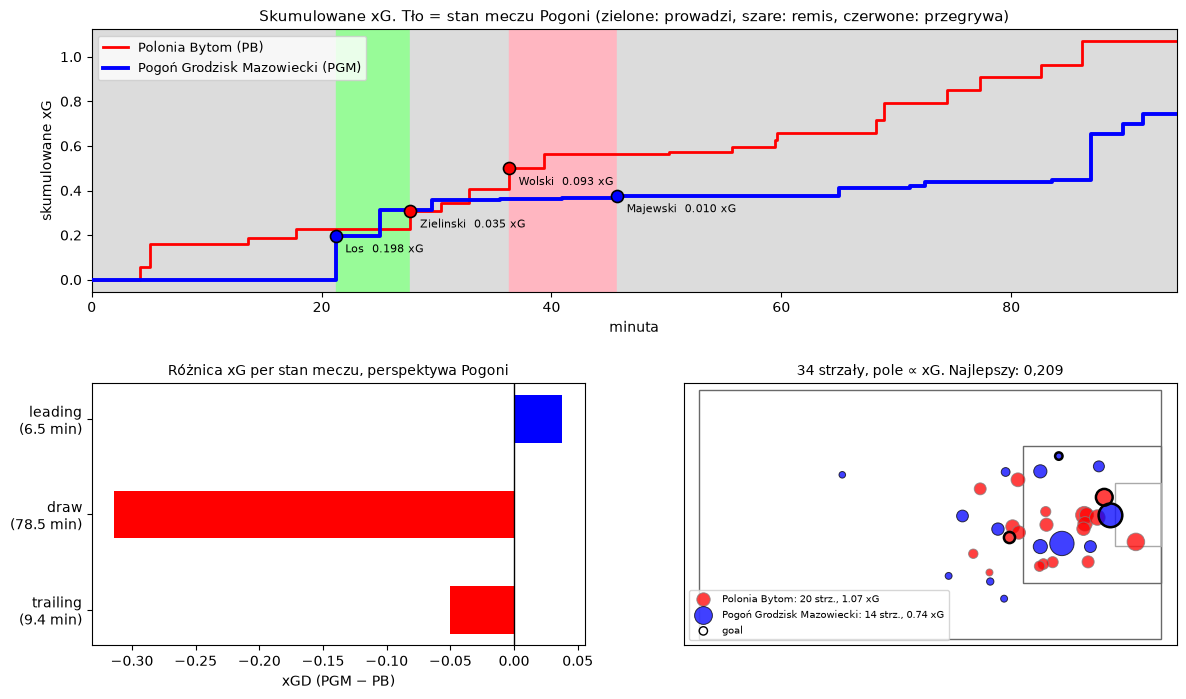

In [8]:
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.2)

ax = fig.add_subplot(gs[0, :])
band = {"leading": "palegreen", "draw": "gainsboro", "trailing": "lightpink"}
for s0, s1 in zip(edges[:-1], edges[1:]):
    gf, ga = score_before(s0 + 1e-9, PGM)
    ax.axvspan(s0 / 60, s1 / 60, color=band[state_of(gf, ga)], zorder=0)
for tm in [PB, PGM]:
    s = shots[shots.team_name == tm].sort_values("t")
    ax.step(np.r_[0, s.t / 60, TOTAL_SEC / 60], np.r_[0, s.statsbomb_xg.cumsum(), s.statsbomb_xg.sum()],
            where="post", color=COL[tm], lw=2.8 if tm == PGM else 2.0,
            label=f"{tm}{' (PGM)' if tm == PGM else ' (PB)'}", zorder=3 if tm == PGM else 2)
for _, g in goals.iterrows():
    cum = shots[(shots.team_name == g.team_name) & (shots.t <= g.t)].statsbomb_xg.sum()
    ax.scatter(g.t / 60, cum, color=COL[g.team_name], s=75, zorder=5, edgecolor="black", lw=1.2)
    ax.annotate(f"{g.player_name.split()[-1]}  {g.statsbomb_xg:.3f} xG", (g.t / 60, cum),
                textcoords="offset points", xytext=(7, -12), fontsize=8)
ax.set_xlabel("minuta"); ax.set_ylabel("skumulowane xG"); ax.margins(x=0)
ax.set_title("Skumulowane xG. Tło = stan meczu Pogoni (zielone: prowadzi, szare: remis, czerwone: przegrywa)",
             fontsize=11)
ax.legend(loc="upper left", fontsize=9)

ax = fig.add_subplot(gs[1, 0])
y = np.arange(3)
vals = [table[table.state == s].xGD.iloc[0] for s in STATES]
ax.barh(y, vals, color=[COL[PGM] if v >= 0 else "red" for v in vals], height=0.5)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n({table[table.state==s].minutes.iloc[0]} min)" for s in STATES])
ax.invert_yaxis(); ax.set_xlabel("xGD (PGM − PB)")
ax.set_title("Różnica xG per stan meczu, perspektywa Pogoni", fontsize=10)

ax = fig.add_subplot(gs[1, 1])
ax.add_patch(Rectangle((60, 0), 60, 80, fill=False, color="dimgray"))
ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, color="dimgray"))
ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, color="darkgray"))
for tm in [PB, PGM]:
    s = shots[shots.team_name == tm]
    ax.scatter(s.location_x, s.location_y, s=s.statsbomb_xg * 1400 + 15, alpha=.75, color=COL[tm],
               edgecolor="black" if tm == PGM else "gray", lw=.7,
               label=f"{tm}: {len(s)} strz., {s.statsbomb_xg.sum():.2f} xG", zorder=3 if tm == PGM else 2)
    g = s[s.outcome_name == "Goal"]
    ax.scatter(g.location_x, g.location_y, s=g.statsbomb_xg * 1400 + 15, facecolor="none",
               edgecolor="black", lw=1.8, zorder=5)
ax.scatter([], [], facecolor="none", edgecolor="black", label="goal")
ax.set_xlim(58, 122); ax.set_ylim(-2, 82); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("34 strzały, pole ∝ xG. Najlepszy: 0,209", fontsize=10)
ax.legend(fontsize=7.5, loc="lower left")
plt.show()

## 5. Mapka strzału

Freeze frame: kto gdzie stał w momencie strzału. Żółte = odsłonięty kawałek bramki.

**Przerywana strzałka** to podanie, po którym padł strzał. Kropki pokazują ustawienie w momencie strzału, a podanie było kilka sekund wcześniej -> dlatego strzałka zwykle wychodzi z pustego miejsca: podający zdążył się stamtąd ruszyć albo w ogóle nie ma go w klatce (freeze frame zawiera tylko zawodników widocznych w kadrze). Przy strzałce jest podpisane, kto podał i ile sekund przed strzałem. Jeśli podający jest w klatce, jego pozycja z momentu strzału ma przerywane obramowanie.

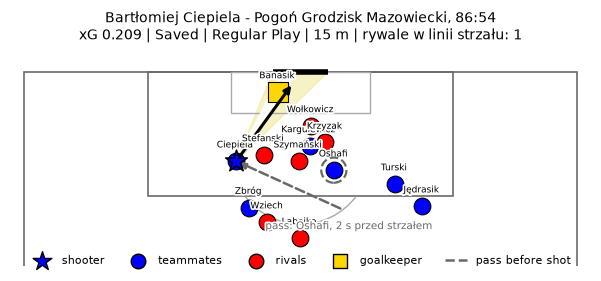

In [9]:
import matplotlib.patheffects as pe

SHOTS_FF = raw[(raw.event_type_name == "Shot") & raw.freeze_frame_player_name.notna()]
POST_L, POST_R, YARD = 36.0, 44.0, 0.9144

def draw_pitch(ax, ymin=59):
    # boisko pionowo, bramka u góry: oś X = location_y, oś Y = location_x
    ax.add_patch(Rectangle((0, 60), 80, 60, fill=False, color="dimgray", lw=1.2))
    ax.add_patch(Rectangle((18, 102), 44, 18, fill=False, color="dimgray", lw=1.2))
    ax.add_patch(Rectangle((30, 114), 20, 6, fill=False, color="darkgray", lw=1.0))
    ax.add_patch(Arc((40, 108), 20, 20, theta1=217, theta2=323, color="darkgray", lw=1.0))
    ax.plot(40, 108, marker="o", ms=2.5, color="dimgray")
    ax.plot([POST_L, POST_R], [120, 120], color="black", lw=4, solid_capstyle="butt")
    ax.set_xlim(-2, 82); ax.set_ylim(ymin, 123.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
    for sp in ax.spines.values():
        sp.set_visible(False)

def blocked_segment(sx, sy, px, py, r=0.9):
    """Kawałek światła bramki zasłonięty przez zawodnika."""
    if px <= sx:
        return None
    k = (120 - sx) / (px - sx)
    if k < 1:
        return None
    c, half = sy + k * (py - sy), k * r
    lo, hi = max(POST_L, c - half), min(POST_R, c + half)
    return (lo, hi) if hi > lo else None

def plot_shot(shot_id, ax=None):
    ff = SHOTS_FF[SHOTS_FF.id == shot_id]
    e = ff.iloc[0]
    own, opp = COL[e.team_name], COL[OPP[e.team_name]]
    sx, sy = e.location_x, e.location_y

    if ax is None:
        _, ax = plt.subplots(figsize=(7.5, 6.5))
    draw_pitch(ax, ymin=max(59, min(ff.freeze_frame_x.min(), sx) - 4))

    ax.add_patch(Polygon([(sy, sx), (POST_L, 120), (POST_R, 120)], color="khaki", alpha=.5, zorder=0))
    n_block = 0
    for _, p in ff.iterrows():
        seg = blocked_segment(sx, sy, p.freeze_frame_x, p.freeze_frame_y)
        if seg and not p.freeze_frame_teammate:
            n_block += 1
            ax.add_patch(Polygon([(sy, sx), (seg[0], 120), (seg[1], 120)], color="white", alpha=.9, zorder=1))

    for _, p in ff.iterrows():
        mate = bool(p.freeze_frame_teammate)
        gk = p.freeze_frame_player_position_name == "Goalkeeper"
        ax.scatter(p.freeze_frame_y, p.freeze_frame_x, s=210 if gk else 145, zorder=3,
                   marker="s" if gk else "o", edgecolor="black", lw=.8,
                   color="gold" if gk else (own if mate else opp))
        ax.annotate(p.freeze_frame_player_name.split()[-1], (p.freeze_frame_y, p.freeze_frame_x),
                    fontsize=6.5, ha="center", va="center", xytext=(0, 12), zorder=7,
                    textcoords="offset points",
                    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

    # Podanie, po którym padł strzał. UWAGA: kropki pokazują ustawienie w momencie STRZAŁU,
    # a strzałka wychodzi z miejsca, w którym podający był kilka sekund wcześniej - dlatego
    # jej początek zwykle jest pusty. Podającego (jeśli jest w klatce) obrysowuję kółkiem.
    a = df[df.assisted_shot_id == shot_id]
    if len(a):
        p = a.iloc[0]
        dt = (e.minute * 60 + e.second) - (p.minute * 60 + p.second)   # ile sekund przed strzałem
        ax.annotate("", xy=(p.end_location_y, p.end_location_x), xytext=(p.location_y, p.location_x),
                    arrowprops=dict(arrowstyle="-|>", lw=1.8, color="dimgray", ls="--"), zorder=4)
        ax.annotate(f"pass: {p.player_name.split()[-1]}, {dt:.0f} s przed strzałem",
                    (p.location_y, p.location_x), fontsize=7.5, color="dimgray",
                    xytext=(0, -14), textcoords="offset points", ha="center", zorder=7,
                    path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])
        moved = ff[ff.freeze_frame_player_name == p.player_name]
        if len(moved):                      # gdzie podający stał w momencie strzału
            ax.scatter(moved.iloc[0].freeze_frame_y, moved.iloc[0].freeze_frame_x, s=330,
                       facecolor="none", edgecolor="dimgray", lw=1.6, ls="--", zorder=8)

    ax.scatter(sy, sx, s=270, marker="*", color=own, edgecolor="black", lw=1.1, zorder=6)
    ax.annotate("", xy=(e.end_location_y, min(e.end_location_x, 120)), xytext=(sy, sx),
                arrowprops=dict(arrowstyle="-|>", lw=2.2, color="black"), zorder=5)

    dist = np.hypot(120 - sx, 40 - sy) * YARD
    ax.set_title(f"{e.player_name} - {e.team_name}, {e.minute}:{str(e.second).zfill(2)}\n"
                 f"xG {e.statsbomb_xg:.3f} | {e.outcome_name} | {e.play_pattern_name} | "
                 f"{dist:.0f} m | rywale w linii strzału: {n_block}", fontsize=10)
    ax.scatter([], [], marker="*", s=200, color=own, edgecolor="black", label="shooter")
    ax.scatter([], [], s=110, color=own, edgecolor="black", label="teammates")
    ax.scatter([], [], s=110, color=opp, edgecolor="black", label="rivals")
    ax.scatter([], [], s=110, marker="s", color="gold", edgecolor="black", label="goalkeeper")
    ax.plot([], [], ls="--", color="dimgray", lw=1.8, label="pass before shot")
    ax.legend(loc="lower center", ncol=5, fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.05))
    return ax

pgm_shots = shots[shots.team_name == PGM]
plot_shot(pgm_shots.loc[pgm_shots.statsbomb_xg.idxmax()].id)
plt.show()

## 6. Cztery gole

Każda bramka na osobnej mapce: ustawienie w momencie strzału, tor strzału i podanie, po którym padł (przerywana strzałka), jeśli jest w danych.

In [10]:
rows = []
for _, g in goals.iterrows():
    a = df[df.assisted_shot_id == g.id]
    ff = SHOTS_FF[SHOTS_FF.id == g.id]
    n_block = sum(1 for _, p in ff.iterrows()
                  if not p.freeze_frame_teammate
                  and blocked_segment(g.location_x, g.location_y, p.freeze_frame_x, p.freeze_frame_y))
    rows.append(dict(clock=f"{g.minute}:{str(g.second).zfill(2)}", team=g.team_name,
                     scorer=g.player_name, xG=round(g.statsbomb_xg, 3),
                     pattern=g.play_pattern_name, body_part=g.body_part_name,
                     distance_m=round(np.hypot(120 - g.location_x, 40 - g.location_y) * YARD, 1),
                     defenders_in_line=n_block,
                     assist=a.iloc[0].player_name if len(a) else "-",
                     state_PGM=state_of(*score_before(g.t, PGM))))
pd.DataFrame(rows)

,clock,team,scorer,xG,pattern,body_part,distance_m,defenders_in_line,assist,state_PGM
0,21:13,Pogoń Grodzisk Mazowiecki,Kacper Los,0.198,From Corner,Head,6.0,3,Bartłomiej Ciepiela,draw
1,27:43,Polonia Bytom,Lucjan Zielinski,0.035,From Throw In,Right Foot,19.2,3,-,leading
2,36:18,Polonia Bytom,Maciej Wolski,0.093,From Throw In,Head,8.4,2,Lucjan Zielinski,draw
3,45:37,Pogoń Grodzisk Mazowiecki,Radoslaw Majewski,0.010,From Kick Off,Left Foot,21.0,2,-,trailing


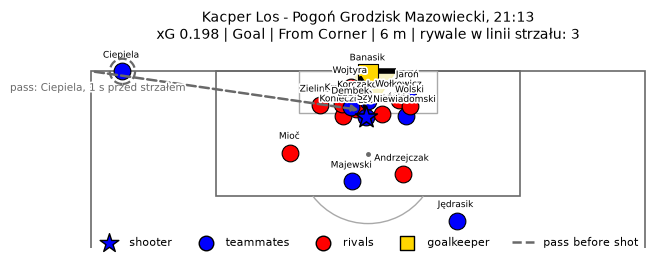

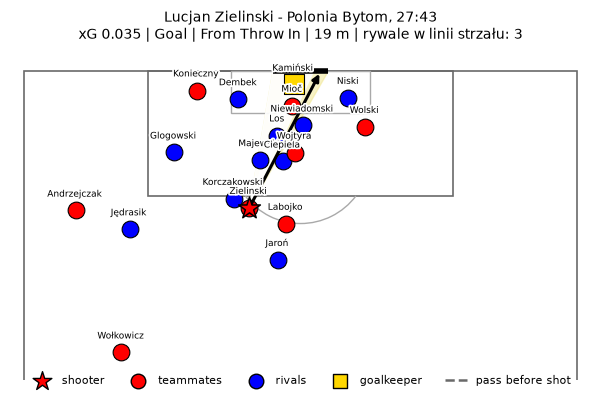

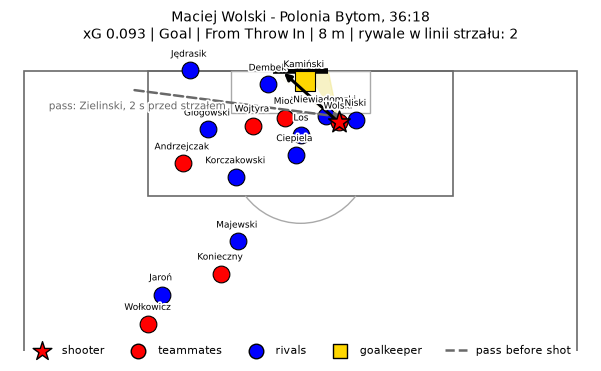

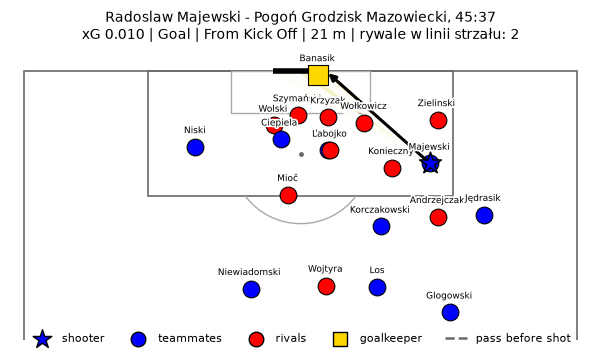

In [11]:
for _, g in goals.iterrows():
    plot_shot(g.id)
    plt.show()

---
Wnioski: **README.md**.